COMPREHENSIVE QUASISYMMETRY WORKFLOW DEMONSTRATION


This notebook demonstrates the complete pipeline for:
1. Generating a molecular Hamiltonian
2. Discovering quasisymmetries (approximate symmetries)
3. Optimizing orbitals to improve quasisymmetry commutation
4. Evaluating subspace decomposition metrics (K value)

The code implements the framework from:
"Optimizing quasisymmetries for quantum subspace expansion"
by Alexey Uvarov and Linjun Wang

KEY CONCEPTS:
- Local parity operator: s_i = 1 - 2*n_i (eigenvalue +1 if unoccupied, -1 if occupied)
- Quasisymmetry: S = product of local parities, approximately commutes with H
- Hilbert space decomposes into sectors based on quasisymmetry eigenvalues (±1)
- Goal: Find orbital rotation that minimizes commutator norms ||[H, S_k]|Ψ⟩||²
- K: Minimal number of sector states needed for chemical accuracy (1.6 mHa)

Dependencies: pyscf, ffsim, numpy, scipy, matplotlib

In [74]:
# choose what molecule to use: 'h2' or 'h2o'
target_molecule = 'h2o'


In [75]:
# ============================================================================
# SECTION 1: HAMILTONIAN GENERATION
# ============================================================================
"""
Create a molecular Hamiltonian for a stretched H2 molecule using PySCF.
This produces a .chk file containing one- and two-electron integrals.

The system: H2 at bond length 2.0 Å (stretched from equilibrium ~0.74 Å)
At this distance, exact D2h symmetries are broken, but quasisymmetries may emerge.
"""

import sys
sys.path.append('../')
import pyscf
import numpy as np
from chemistry import get_geometry_and_description


if target_molecule == 'h2':
    

    # --- Step 1.1: Define molecular geometry ---
    molecule = "h2"
    bond_length = .7  # Angstroms - 2.0 is stretched configuration; 0.74 is equilibrium; for -> infty code gives MOs = AOs
    geometry, description = get_geometry_and_description(molecule, bond_length)
    print(f"Geometry: {geometry}")
    print(f"Description: {description}")

    # --- Step 1.2: Build PySCF molecule and run Hartree-Fock ---
    mol = pyscf.M()
    mol.build(atom=geometry, basis="sto-3g")  # Minimal basis for demonstration
    mf = pyscf.scf.RHF(mol)
    mf.chkfile = f"hamiltonians/{description}.chk"  # Will save to this file
    mf.kernel()  # Run SCF calculation

    # !! From now on and until we start doing orbital rotations, the "orbitals" are always the HF MOs we just obtained.

    print(f"HF Energy: {mf.e_tot:.8f} Hartree")
    print(f"Number of orbitals: {mol.nao}")
    print(f"Number of electrons: {mol.nelec}")
    print(f"Coeffs of MOs:\n{mf.mo_coeff}")

    """
    NOTES ON SECTION 1:
    - The .chk file contains all molecular data needed for FCI
    - STO-3G basis for H2 gives 2 spatial orbitals (1s on each H)
    - Total Hilbert space dimension: C(2,1) * C(2,1) = 4 for singlet (but we use alpha/beta separately; we now GS of H2 is singlet -> Sz = 0 determinants only)
    - For H2 with 2 electrons in STO-3G: norb=2, nelec=(1,1) (alpha, beta) -> 4 determinants
    """
    print("\n")

In [76]:
# ============================================================================
# SECTION 2: QUASISYMMETRY DISCOVERY
# ============================================================================
"""
Use show_symmetries.py logic to visualize which products of local parities
have small commutator norms with the Hamiltonian for a reference state.

With i spatial orbital index, and s_i = (1 - 2n_iα)(1 - 2n_iβ), what show_symmetries.py does is:
 1. 
Computes non-commutativity scores for:
• Individual local parities: NC(i,i) = ||[H, s_i]|Ψ⟩||² (diagonal)
• Pairwise products: NC(i,j) = ||[H, s_i s_j]|Ψ⟩||² (off-diagonal)
 2. 
Visualizes results as a heatmap (log scale) where:
• Dark spots = small commutator = good quasisymmetry candidate
• Bright spots = poor candidates

We test:
- Individual parities: s_0, s_1, ... (diagonal of heatmap)
- Pairwise products: s_0*s_1, s_0*s_2, ... (off-diagonal)
"""

if target_molecule == 'h2':

    import ffsim
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    from optimize_orbitals import parities, get_fci

    # --- Step 2.1: Load molecular data using objects mol and mf from previous cell ---
    moldata = pyscf.lib.chkfile.load_mol(mf.chkfile)
    mf_update = pyscf.scf.RHF(mol)
    mf_update.update_from_chk(mf.chkfile)
    moldata_ffsim = ffsim.MolecularData.from_scf(mf_update)

    # Prepare the molecular integrals in FCI-compatible format needed by PySCF's FCI solver.
    dumpdata = { # (dump means save/write out)
        "NORB": mol.nao,
        "NELEC": mol.nelec,
        "H1": mf.mo_coeff.T @ (mol.intor("int1e_kin") + mol.intor("int1e_nuc")) @ mf.mo_coeff,
        "H2": pyscf.ao2mo.full(mol, mf.mo_coeff),
        "ECORE": mol.energy_nuc()
    }

    # --- Step 2.2: Compute FCI reference state ---
    e_fci, fci_state = get_fci(dumpdata) # optimize_orbitals.get_fci calls pyscf.fci.direct_spin1.FCI
    print(f"\nFCI Energy: {e_fci:.8f} Hartree")
    print(f"FCI state: {fci_state}")

    # --- Step 2.3: Define local parity operators ---
    # For each spatial orbital i, s_i = (1-2n_i_alpha)(1-2n_i_beta)
    # This is the SPATIAL orbital parity (both spins together)
    local_parities = parities(moldata_ffsim.norb, moldata_ffsim.nelec) # optimize_orbitals.parities uses ffsim, the recent qiskit software for classical simulations
    print(f"\nNumber of local parities (should be as many as orbitals): {len(local_parities)}")
    example_parity_op = local_parities[0]
    print(f"\nVariable type of each parity operator: {type(example_parity_op)}")
    # SciPy's matrix-free linear operator: a lightweight wrapper that knows how to apply the (sparse) operator to a vector. Can also use @, eigsh, ... with it. Good to keep in mind!

    # --- Step 2.4: Compute commutator norms ---
    norb = moldata_ffsim.norb
    h = ffsim.linear_operator(moldata_ffsim.hamiltonian, norb, moldata_ffsim.nelec) # the hamiltonian refers to HF MO orbital basis; this is the line of this cell where we are choosing the reference orbital basis
    print(f"\nVariable type of h: {type(h)}") # same "wrapper" type

    # Initialize heatmap matrix
    nc_scores = np.zeros((norb, norb))

    # Diagonal: ||[H, s_i]|Ψ⟩||² for individual parities
    for i in range(norb):
        commutator = h @ local_parities[i] - local_parities[i] @ h # using the wrapper variable type. Commutator has same/related type
        nc_scores[i, i] = np.linalg.norm(commutator @ fci_state)**2
        print(f"||[H, s_{i}]|Ψ>||² = {nc_scores[i,i]:.6e}")

    # Off-diagonal: ||[H, s_i * s_j]|Ψ⟩||² for pairs
    for i in range(norb):
        for j in range(i+1, norb):
            s_ij = local_parities[i] @ local_parities[j]
            commutator = h @ s_ij - s_ij @ h
            nc_scores[i, j] = np.linalg.norm(commutator @ fci_state)**2
            print(f"||[H, s_{i}s_{j}]|Ψ>||² = {nc_scores[i,j]:.6e}")

    # --- Step 2.5: Visualize the non-commutativity heatmap ---
    plt.figure(figsize=(8, 6))
    plt.imshow(nc_scores, norm=LogNorm(vmin=1e-8, vmax=1), cmap='viridis')
    plt.colorbar(label='Non-commutativity norm (log scale)')
    plt.xticks(range(norb), [f's_{i}' for i in range(norb)])
    plt.yticks(range(norb), [f's_{i}' for i in range(norb)])
    plt.title('Quasisymmetry Discovery for H2')

    # Add text annotations for exact values
    for i in range(norb):
        for j in range(norb):
            if i <= j:  # Only show upper triangle
                plt.text(j, i, f'{nc_scores[i,j]:.2e}',
                        ha='center', va='center', color='white' if nc_scores[i,j] > 1e-2 else 'black')

    plt.tight_layout()
    plt.show()

    """
    NOTES ON SECTION 2:
    - Dark spots in the heatmap indicate good quasisymmetry candidates
    - The s_0 and s_1 commutator things for H2 in minimal basis is zero because, roughly, on 2-particle sector parity of sigma occupation (s_0) = parity of sigma* occupation (s_1) = 1P-unitary (inversion about symmetry plane) \otimes (inversion about symmetry plane) which does commute with the Hamiltonian!
    - The s_0 * s_1 thin also zero because this (Q)S is already the *total* number parity
    """

    print("\n")

<>:99: SyntaxWarning: invalid escape sequence '\o'
<>:99: SyntaxWarning: invalid escape sequence '\o'
/var/folders/r2/2ny_rjqj5w93mz1ll0gd2vbr0000gp/T/ipykernel_65546/24170944.py:99: SyntaxWarning: invalid escape sequence '\o'
  """


converged SCF energy = -74.9646625391309

FCI Energy: -75.01985480 Hartree
Number of FCI state coefficients: 441


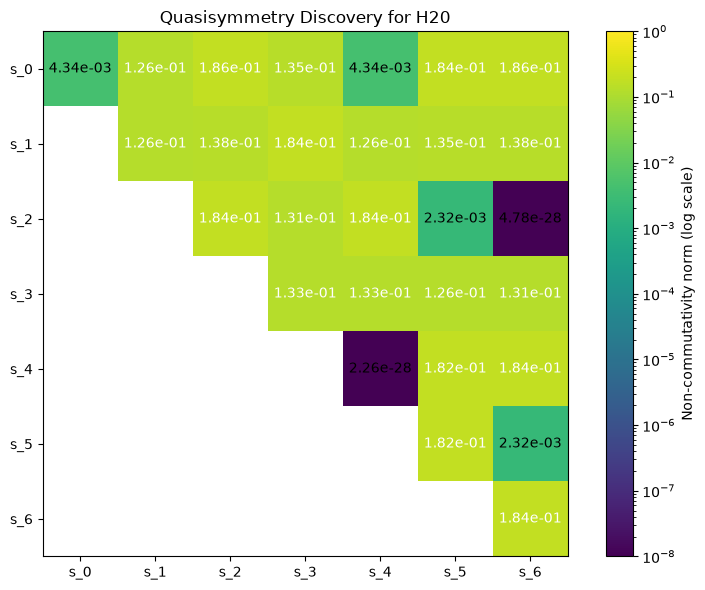

In [77]:
# same as above, for h2o; here, just the basic code

if target_molecule == 'h2o':

    import scipy.optimize
    from math import comb
    from chemistry import load_moldata, fcidump_data
    from optimize_orbitals import (parities, get_fci, parity_matrix_to_quasisymmetries,
                                commutator_cost, x_to_rotation)
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    from optimize_orbitals import parities, get_fci
    import ffsim


    molecule = "h2o"
    bond_length = 1. 
    hoh_angle_deg=104.5
    geometry, description = get_geometry_and_description(molecule, bond_length, hoh_angle_deg=hoh_angle_deg)
    mol = pyscf.M()
    mol.build(atom=geometry, basis="sto-3g")
    mf = pyscf.scf.RHF(mol)
    mf.chkfile = f"hamiltonians/{description}.chk"
    mf.kernel()
    moldata = pyscf.lib.chkfile.load_mol(mf.chkfile)
    mf_update = pyscf.scf.RHF(mol)
    mf_update.update_from_chk(mf.chkfile)
    moldata_ffsim = ffsim.MolecularData.from_scf(mf_update)
    dumpdata = { # (dump means save/write out)
        "NORB": mol.nao,
        "NELEC": mol.nelec,
        "H1": mf.mo_coeff.T @ (mol.intor("int1e_kin") + mol.intor("int1e_nuc")) @ mf.mo_coeff,
        "H2": pyscf.ao2mo.full(mol, mf.mo_coeff),
        "ECORE": mol.energy_nuc()
    }
    e_fci, fci_state = get_fci(dumpdata)
    print(f"\nFCI Energy: {e_fci:.8f} Hartree")
    print(f"Number of FCI state coefficients: {len(fci_state)}")
    local_parities = parities(moldata_ffsim.norb, moldata_ffsim.nelec)
    example_parity_op = local_parities[0]
    norb = moldata_ffsim.norb
    h = ffsim.linear_operator(moldata_ffsim.hamiltonian, norb, moldata_ffsim.nelec)
    nc_scores = np.zeros((norb, norb))
    # Diagonal:
    for i in range(norb):
        commutator = h @ local_parities[i] - local_parities[i] @ h
        nc_scores[i, i] = np.linalg.norm(commutator @ fci_state)**2
    # Off-diagonal:
    for i in range(norb):
        for j in range(i+1, norb):
            s_ij = local_parities[i] @ local_parities[j]
            commutator = h @ s_ij - s_ij @ h
            nc_scores[i, j] = np.linalg.norm(commutator @ fci_state)**2
    plt.figure(figsize=(8, 6))
    plt.imshow(nc_scores, norm=LogNorm(vmin=1e-8, vmax=1), cmap='viridis')
    plt.colorbar(label='Non-commutativity norm (log scale)')
    plt.xticks(range(norb), [f's_{i}' for i in range(norb)])
    plt.yticks(range(norb), [f's_{i}' for i in range(norb)])
    plt.title('Quasisymmetry Discovery for H20')

    # Add text annotations for exact values
    for i in range(norb):
        for j in range(norb):
            if i <= j:  # Only show upper triangle
                plt.text(j, i, f'{nc_scores[i,j]:.2e}',
                        ha='center', va='center', color='white' if nc_scores[i,j] > 1e-2 else 'black')

    plt.tight_layout()
    plt.show()


In [78]:
# ============================================================================
# SECTION 3: ORBITAL OPTIMIZATION
# ============================================================================
"""
Now we:
1. Select one or more quasisymmetries (based on heatmap) by defining a parity matrix
2. Optimize the orbital rotation to minimize the commutator cost

The parity matrix is a binary matrix where:
- Rows = different quasisymmetries we want to use
- Columns = spatial orbitals (or spin-orbitals if 2*norb columns)
- Entry [i,j] = 1 if orbital j is included in quasisymmetry i, 0 otherwise
"""

from optimize_orbitals import (parity_matrix_to_quasisymmetries,
                             commutator_cost, x_to_rotation)
import scipy.optimize
from math import comb

# --- Step 3.1: Define the parity matrix ---
# Based on our heatmap, let's use S = s_0 * s_1 as our quasisymmetry
# This is a single quasisymmetry using both orbitals
if target_molecule == 'h2o':
    parity_matrix = np.array([ # here we go for spinful orbitals
        [0, 0, 1, 0, 1, 0, 1],  # Two quasisymmetry: one includes orbitals 2, 4, 6...
        [1, 0, 0, 0, 1, 0, 0] # ... the other onw 0 and  4
    ])
    # or the following bad ones...
    parity_matrix = np.array([ # here we go for spinful orbitals
        [0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 1],
        [1, 1, 0, 0, 0, 1, 0]
    ])
if target_molecule == 'h2':
    parity_matrix = np.array([[1, 0]]) # just first orbital, for hydrogen
print(f"\nParity matrix ({parity_matrix.shape[0]} quasisymmetries, {parity_matrix.shape[1]} orbitals):")
print(parity_matrix)

# --- Step 3.2: Convert parity matrix to quasisymmetry operators ---
symmetries = parity_matrix_to_quasisymmetries(
    parity_matrix, moldata_ffsim.norb, moldata_ffsim.nelec)
print(f"Number of quasisymmetry operators: {len(symmetries)}")

# --- Step 3.3: Define the cost function ---
# Cost = sum over symmetries S_k of ||[H(U), S_k]|Ψ(U)⟩||²
# We optimize over orbital rotation parameters x (anti-symmetric matrix)
f = commutator_cost(moldata_ffsim, symmetries, fci_state) # commutator_cost builds the cost function f: x antisym matrix |-> \sum_k ||[H(rotated with exp(x)), S_k]|Ψ(rotated with exp(x)⟩||²

# --- Step 3.4: Initial guess (identity rotation) ---
x0 = np.zeros(comb(norb, 2))  # For norb=2, this is 1 parameter
initial_cost = f(x0)
print(f"\nInitial cost (identity rotation): {initial_cost:.6e}")

# --- Step 3.5: Optimize using L-BFGS-B ---
print("\nRunning orbital optimization...")
result = scipy.optimize.minimize(
    f, x0,
    method='L-BFGS-B',
    options={'maxiter': 50, 'disp': True}
)
optimized_cost = result.fun
print(f"Optimized cost: {optimized_cost:.6e}")
print(f"Cost reduction: {(initial_cost - optimized_cost)/initial_cost * 100:.2f}%")

# --- Step 3.6: Extract optimized orbital rotation ---
x_opt = result.x
U_opt = x_to_rotation(x_opt, norb)
print(f"\nOptimized rotation matrix U:")
print(U_opt)

"""
NOTES ON SECTION 3:
- The optimization finds U that minimizes the commutator norm
- The orbital rotation U transforms the molecular orbitals to a new basis
where the quasisymmetry commutes better with the Hamiltonian.
"""

print("\n")



Parity matrix (3 quasisymmetries, 7 orbitals):
[[0 1 0 0 0 0 0]
 [0 0 0 1 0 1 1]
 [1 1 0 0 0 1 0]]
Number of quasisymmetry operators: 3

Initial cost (identity rotation): 3.945803e-01

Running orbital optimization...


/var/folders/r2/2ny_rjqj5w93mz1ll0gd2vbr0000gp/T/ipykernel_65546/4128050232.py:56: OptimizeWarning: Unknown solver options: disp
  result = scipy.optimize.minimize(


Optimized cost: 3.672438e-01
Cost reduction: 6.93%

Optimized rotation matrix U:
[[ 9.99935884e-01 -1.09899927e-02  7.71882707e-08  2.72596798e-03
  -9.58166323e-08 -1.31366433e-04 -2.25828817e-07]
 [ 1.13191704e-02  9.63248457e-01  1.44001826e-05 -2.68219920e-01
  -9.39271438e-07  9.07530992e-03  4.93419833e-06]
 [-2.40140603e-07 -1.42911268e-05  9.99995384e-01  2.41575022e-06
  -6.74799491e-07  1.61676547e-07  3.03846188e-03]
 [ 3.22030287e-04  2.68223293e-01  1.97925896e-06  9.63353825e-01
  -1.54886197e-06  2.35462523e-03 -1.55856273e-04]
 [ 1.06940245e-07  1.31926276e-06  6.77021002e-07  1.24032072e-06
   1.00000000e+00 -4.88229290e-09 -7.24873940e-07]
 [ 2.78759954e-05 -9.37519956e-03 -2.90302430e-07  1.66206754e-04
   1.70401251e-08  9.99956038e-01 -1.89086584e-06]
 [ 2.20937215e-07  3.70748103e-05 -3.03846168e-03  1.51462479e-04
   7.26690901e-07  2.21247577e-06  9.99995372e-01]]





Number of alpha/beta elecs: (5, 5)
Corresponding total number of configurations = total dimension: 441
Number of symmetry sectors identified: 8
  Sector (0, 0, 0): 71 configurations
  Sector (0, 1, 1): 64 configurations
  Sector (0, 0, 1): 64 configurations
  Sector (1, 1, 0): 46 configurations
  Sector (0, 1, 0): 62 configurations
  Sector (1, 1, 1): 44 configurations
  Sector (1, 0, 0): 46 configurations
  Sector (1, 0, 1): 44 configurations
Sectors full dict: {(0, 0, 0): [0, 7, 14, 19, 22, 24, 31, 32, 36, 44, 54, 64, 66, 73, 74, 78, 88, 100, 110, 111, 113, 122, 131, 132, 134, 143, 147, 154, 161, 166, 173, 174, 176, 185, 198, 211, 213, 220, 221, 225, 232, 234, 241, 242, 246, 254, 264, 286, 291, 294, 301, 308, 313, 316, 318, 325, 326, 330, 340, 352, 362, 363, 365, 374, 391, 396, 399, 406, 413, 418, 440], (0, 1, 1): [1, 3, 10, 11, 15, 21, 28, 35, 40, 47, 48, 50, 59, 63, 70, 77, 82, 104, 107, 117, 128, 138, 148, 150, 157, 158, 162, 170, 180, 202, 207, 210, 217, 224, 229, 231, 238, 245,

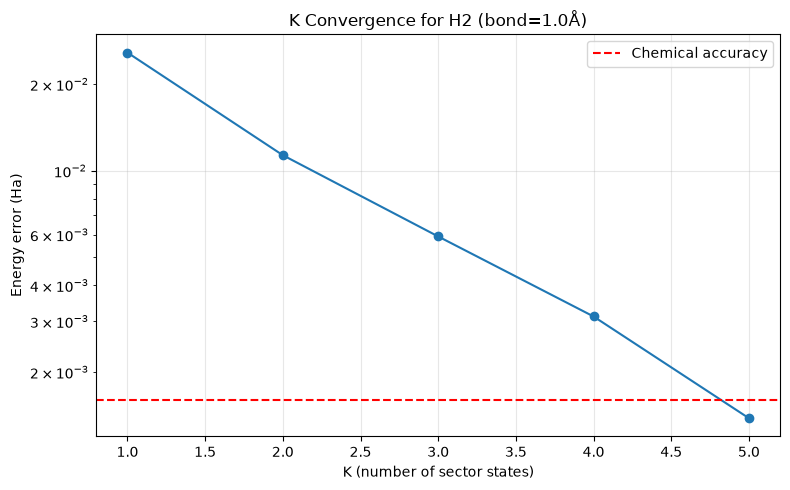

In [79]:
# ============================================================================
# SECTION 4: METRICS EVALUATION
# ============================================================================
"""
Now we evaluate the quality of the subspace decomposition by:
1. Identifying symmetry sectors
2. Building subspace Hamiltonians
3. Computing K: minimal number of states needed for chemical accuracy

Chemical accuracy = 1.6 mHa = 0.0016 Hartree
"""

from metrics import symmetry_sectors, subspace_matrix, orthogonalize_degenerate
from chemistry import CHEMICAL_PRECISION
from math import comb


# for hydrogen, let's change U_opt to get nonzero stuff
if target_molecule == 'h2':
    theta = .5
    U_opt = np.array([[np.cos(theta),np.sin(theta)],[np.sin(theta), -np.cos(theta)]])

# --- Step 4.1: Apply optimized rotation to Hamiltonian and state ---
rotated_h = moldata_ffsim.hamiltonian.rotated(U_opt)
rotated_h_linop = ffsim.linear_operator(rotated_h, norb, moldata_ffsim.nelec)
rotated_fci_state = ffsim.apply_orbital_rotation(
    fci_state, U_opt, norb, moldata_ffsim.nelec)

# --- Step 4.2: Identify symmetry sectors by partitioning the computational/fock basis --- 
# Each configuration/bitstring/basis SD gets assigned to a sector based on
# the eigenvalues of our quasisymmetries
sectors = symmetry_sectors(parity_matrix, norb, moldata_ffsim.nelec)
print(f"\nNumber of alpha/beta elecs: {moldata_ffsim.nelec}")
print(f"Corresponding total number of configurations = total dimension: {comb(norb, moldata_ffsim.nelec[0]) * comb(norb, moldata_ffsim.nelec[1])}")
print(f"Number of symmetry sectors identified: {len(sectors)}")
for sector_label, sector_indices in sectors.items():
    print(f"  Sector {sector_label}: {len(sector_indices)} configurations")
print(f"Sectors full dict: {sectors} \n")

# --- Step 4.3: Build subspace Hamiltonians ---
sector_hamiltonians = {}
for sector_label, sector_indices in sectors.items():
    sector_hamiltonians[sector_label] = subspace_matrix(
        rotated_h_linop, sector_indices)
    print(f"  Sector {sector_label}: Hamiltonian shape {sector_hamiltonians[sector_label].shape}")

print(" ")

# --- Step 4.4: Diagonalize each sector ---
sector_energies = {}
sector_states = {}
for label, h_sub in sector_hamiltonians.items():
    # Get all eigenvalues (full diagonalization for small systems)
    w, v = np.linalg.eigh(h_sub)
    v_orth = orthogonalize_degenerate(w, v)
    sector_energies[label] = w
    sector_states[label] = v_orth
    print(f"  Sector {label}: {len(w)} states, ground energy = {w[0]:.8f}")

# --- Step 4.5: Find the global ground state in decoupled sectors ---
# Each sector has its own ground state. The true ground state is the minimum.
sector_ground_energies = {label: energies[0] for label, energies in sector_energies.items()}
global_min_sector = min(sector_ground_energies, key=sector_ground_energies.get)
e_decoupled = sector_ground_energies[global_min_sector]
print(f"\nDecoupled ground state energy: {e_decoupled:.8f}")
print(f"FCI energy: {e_fci:.8f}")
print(f"Energy error: {e_decoupled - e_fci:.8f} Hartree = {(e_decoupled - e_fci)*27.2114:.4f} eV")

# --- Step 4.6: Construct full-space basis from sector states ---
# Collect all sector states into a single matrix
full_space_vectors = []
sector_labels_list = []
for label, indices in sectors.items():
    # Get the states for this sector
    v_sector = sector_states[label]
    n_states = v_sector.shape[1]

    # Create full-space vectors (zeros everywhere except in this sector)
    vectors_in_sector = np.zeros((rotated_h_linop.shape[0], n_states),
                                dtype='complex')
    vectors_in_sector[indices, :] = v_sector
    full_space_vectors.append(vectors_in_sector)

    # Track which sector each state belongs to
    for i in range(n_states):
        sector_labels_list.append((label, i))

print(f"\n Full space vectors (each column is an eigenvector of the QSs and of the hamiltonian restricted to the corresponding QS sector): \n{full_space_vectors}") # basis ordering for two orbitals and Nalpha = Nbeta = 1: |alpha beta, 0>, |alpha, beta>, |beta, alpha>, |0, alpha beta>
print(f"\n Sector labels list (QS label of the vectors just printed): \n{sector_labels_list}")

# Concatenate all sector states
full_space_vectors_cat = np.concatenate(full_space_vectors, axis=1) # block diag unitary up to reordering only columns or only rows, i.e., full change of basis matrix from initial SDs to basis of sim. eigenvectors of the QSs and of the hamiltonian restricted
print(f"\n full_space_vectors_cat: \n {full_space_vectors_cat}")
print(f"\nTotal number of sector states: {full_space_vectors_cat.shape[1]}")
print(f"Full Hilbert space dimension: {rotated_h_linop.shape[0]}")

# --- Step 4.7: Project FCI state onto sector states ---
# This tells us how much of the FCI state lives in each sector
coefficients = full_space_vectors_cat.T.conj() @ rotated_fci_state
print(f"\nFCI state coefficients in sector basis:")
for i, (label, state_idx) in enumerate(sector_labels_list):
    print(f"  Sector {label}, state {state_idx}: |c|² = {np.abs(coefficients[i])**2:.9f}")

# --- Step 4.8: Calculate K directly ---
"""
K is the minimal number of sector states *distributed across sectors*
needed to recover the FCI ground state energy to chemical accuracy.

We sort sector states by their contribution to the FCI state and
accumulate until the projected energy is within 0.0016 Ha of FCI.
"""

# Sort coefficients by magnitude (most important first)
sorted_indices = np.argsort(np.abs(coefficients))[::-1]

# Function to compute projected energy using top K states
def projected_energy(K):
    """Compute energy using only the K most important sector states"""
    # Create compressed coefficient vector
    compressed_coeffs = np.zeros_like(coefficients, dtype='complex')
    compressed_coeffs[sorted_indices[:K]] = coefficients[sorted_indices[:K]]

    # Normalize
    compressed_coeffs /= np.linalg.norm(compressed_coeffs)

    # Projected state in full space
    projected_state = full_space_vectors_cat @ compressed_coeffs
    projected_state /= np.linalg.norm(projected_state) # redundant

    # Compute energy
    e_proj = projected_state.T.conj() @ rotated_h_linop @ projected_state
    return e_proj.real



# Find minimal K
K_values = []
energies = []
for K in range(1, len(coefficients) + 1):
    e_K = projected_energy(K)
    energies.append(e_K)
    K_values.append(K)
    error = e_K - e_fci
    print(f"  K={K:2d}: E={e_K:.8f}, Error={error:.8f} Ha = {error*27.2114:.4f} eV")
    if error < CHEMICAL_PRECISION:
        print(f"  --> Chemical accuracy achieved at K={K}!")
        break

# Plot energy error vs K
plt.figure(figsize=(8, 5))
plt.plot(K_values, [e - e_fci for e in energies], 'o-')
plt.axhline(CHEMICAL_PRECISION, color='r', linestyle='--', label='Chemical accuracy')
plt.axhline(0, color='k', linestyle=':', alpha=0.3)
plt.xlabel('K (number of sector states)')
plt.ylabel('Energy error (Ha)')
plt.title(f'K Convergence for H2 (bond={bond_length}Å)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

"""
NOTES ON SECTION 4:
- K=1 means the ground state of a single sector recovers chemical accuracy
- For well-chosen quasisymmetries, K is much smaller than the full Hilbert space
- For H2 at 2.0Å with STO-3G: full space has 4 states, we often get K=1 or K=2
- The energy error plot shows how quickly we converge to FCI

PHYSICAL INTERPRETATION:
When K is small, it means the quasisymmetry successfully decomposes the
Hilbert space such that the ground state is well-approximated by a small
number of states from a few sectors. This is the power of quasisymmetries:
they enable efficient subspace methods even when exact symmetries are broken.
"""

print("\n")

In [80]:

# ============================================================================
# SECTION 5: COMPLETE WORKFLOW SUMMARY
# ============================================================================


print("\n" + "="*70)
print("WORKFLOW SUMMARY")
print("="*70)
print(f"Molecule: {target_molecule} at {bond_length}Å bond length")
if target_molecule == 'h2o':
    print(f"Bond angle: {hoh_angle_deg}")
print(f"Basis: STO-3G ({norb} spatial orbitals)")
print(f"Electrons: {mol.nelec}")
print()
print(f"1. Hamiltonian Generation:")
print(f"   - HF Energy: {mf.e_tot:.8f} Ha")
print(f"   - FCI Energy: {e_fci:.8f} Ha")
print()
print(f"2. Quasisymmetry Discovery:")
print(f"   - Tested {norb} individual parities and {comb(norb,2)} pairs")
print()
print(f"3. Orbital Optimization:")
print(f"   - Initial cost: {initial_cost:.6e}")
print(f"   - Optimized cost: {optimized_cost:.6e}")
print(f"   - Cost reduction: {(initial_cost - optimized_cost)/initial_cost * 100:.2f}%")
if target_molecule == 'h2':
    print("Selected random orbital rotation for h2 to get non boring output")
print()
print(f"4. Metrics Evaluation:")
print(f"   - Number of sectors: {len(sectors)}")
print(f"   - Decoupled ground energy: {e_decoupled:.8f} Ha")
print(f"   - Energy error (decoupled): {e_decoupled - e_fci:.8f} Ha")
print(f"   - K value: {K} sector states needed for chemical accuracy")
print(f"   - Full space dimension: {rotated_h_linop.shape[0]}")
print()
print("INTERPRETATION:")
if K == 1:
    print("  ✓ Excellent: K=1 means a single sector state recovers chemical accuracy!")
    print("  The quasisymmetry perfectly (or nearly perfectly) decomposes the space.")
elif K < rotated_h_linop.shape[0]:
    print(f"  ✓ Good: K={K} < {rotated_h_linop.shape[0]} strictly, means space dim reduction")
    print(f"  Only {K}/{rotated_h_linop.shape[0]} of the space needed.")
else:
    print("  ✗ Poor: K equals full space dimension - no benefit from quasisymmetry")
print("="*70)


WORKFLOW SUMMARY
Molecule: h2o at 1.0Å bond length
Bond angle: 104.5
Basis: STO-3G (7 spatial orbitals)
Electrons: (5, 5)

1. Hamiltonian Generation:
   - HF Energy: -74.96466254 Ha
   - FCI Energy: -75.01985480 Ha

2. Quasisymmetry Discovery:
   - Tested 7 individual parities and 21 pairs

3. Orbital Optimization:
   - Initial cost: 3.945803e-01
   - Optimized cost: 3.672438e-01
   - Cost reduction: 6.93%

4. Metrics Evaluation:
   - Number of sectors: 8
   - Decoupled ground energy: -74.99411958 Ha
   - Energy error (decoupled): 0.02573522 Ha
   - K value: 5 sector states needed for chemical accuracy
   - Full space dimension: 441

INTERPRETATION:
  ✓ Good: K=5 < 441 strictly, means space dim reduction
  Only 5/441 of the space needed.


In [81]:

# ============================================================================
# SECTION 6: EXPLANATION OF KEY FUNCTIONS
# ============================================================================
"""
This section provides deeper explanation of the core functions used above.
"""

print("\n" + "="*70)
print("KEY FUNCTION EXPLANATIONS")
print("="*70)

print("""
1. parities(norb, nelec) -> List[LinearOperator]
   - Creates local parity operators s_i for each spatial orbital
   - s_i = (1 - 2n_iα)(1 - 2n_iβ) = orbital parity
   - Returns as linear operators in the Fock space

2. parity_matrix_to_quasisymmetries(parity_matrix, norb, nelec) -> List[LinearOperator]
   - Converts binary matrix to quasisymmetry operators
   - Each row defines a quasisymmetry as product of local parities
   - If matrix has 2*norb columns: treats alpha/beta separately
   - If matrix has norb columns: treats spatial orbitals (both spins together)

3. commutator_cost(moldata, symmetries, reference_state) -> Callable
   - Returns function f(x) that computes:
     Cost = Σ_k ||[H(U(x)), S_k] |Ψ(U(x))⟩||²
   - x: vector of orbital rotation parameters (upper triangle of anti-symmetric matrix)
   - U(x): unitary rotation matrix from x via matrix exponential
   - Used as objective for orbital optimization

4. x_to_rotation(x, norb) -> ndarray
   - Converts parameter vector x to unitary rotation matrix U
   - x represents upper triangle of anti-symmetric generator G
   - U = exp(G) where G[i,j] = x[k] for i<j, G[j,i] = -x[k], G[i,i] = 0

5. symmetry_sectors(parity_matrix, norb, nelec) -> Dict[Tuple, List[int]]
   - Identifies which configurations belong to which symmetry sector
   - For each bitstring (Fock state), computes quasisymmetry eigenvalues
   - Returns: {sector_label: [list of configuration indices]}
   - Sector label is tuple of eigenvalues (+1/-1) for each quasisymmetry

6. subspace_matrix(A, support) -> ndarray
   - Extracts submatrix of A corresponding to specified support indices
   - Used to build Hamiltonian restricted to a symmetry sector

7. get_fci(dumpdata) -> (float, ndarray)
   - Runs Full Configuration Interaction using PySCF's direct_spin1.FCI
   - Returns (energy, state_vector)
   - State vector in Fock basis (spin-orbital ordering)
""")

print("="*70)



KEY FUNCTION EXPLANATIONS

1. parities(norb, nelec) -> List[LinearOperator]
   - Creates local parity operators s_i for each spatial orbital
   - s_i = (1 - 2n_iα)(1 - 2n_iβ) = orbital parity
   - Returns as linear operators in the Fock space

2. parity_matrix_to_quasisymmetries(parity_matrix, norb, nelec) -> List[LinearOperator]
   - Converts binary matrix to quasisymmetry operators
   - Each row defines a quasisymmetry as product of local parities
   - If matrix has 2*norb columns: treats alpha/beta separately
   - If matrix has norb columns: treats spatial orbitals (both spins together)

3. commutator_cost(moldata, symmetries, reference_state) -> Callable
   - Returns function f(x) that computes:
     Cost = Σ_k ||[H(U(x)), S_k] |Ψ(U(x))⟩||²
   - x: vector of orbital rotation parameters (upper triangle of anti-symmetric matrix)
   - U(x): unitary rotation matrix from x via matrix exponential
   - Used as objective for orbital optimization

4. x_to_rotation(x, norb) -> ndarray
   - 

In [82]:

# ============================================================================
# SECTION 7: PRACTICAL TIPS FOR USING THE CODE
# ============================================================================
"""
Based on the authors' workflow and common use cases.
"""

print("\n" + "="*70)
print("PRACTICAL USAGE TIPS")
print("="*70)

print("""
WORKFLOW RECOMMENDATIONS:

1. START WITH VISUALIZATION:
   - Always run show_symmetries.py first to see the heatmap
   - Look for dark spots (small commutator norms)
   - These indicate good quasisymmetry candidates

2. CHOOSING QUASISYMMETRIES:
   - Start with single quasisymmetry (1 row in parity matrix)
   - If heatmap shows dark diagonal: try individual s_i
   - If heatmap shows dark off-diagonal: try s_i * s_j
   - For larger systems: look for blocks of dark pixels (higher-order products)

3. PARITY MATRIX FORMAT:
   - Each row = one quasisymmetry
   - Each column = one spatial orbital (or spin-orbital if 2*norb columns)
   - Example for 4 orbitals, using s0*s1 and s2*s3:
     [[1, 1, 0, 0],
      [0, 0, 1, 1]]

4. ORBITAL OPTIMIZATION:
   - Start with identity (x0 = zeros)
   - Use L-BFGS-B (default in code) - works well for this problem
   - Monitor cost reduction; if <10% improvement, try different quasisymmetries

5. METRICS EVALUATION:
   - Always use --direct_K for most reliable K calculation
   - Start with states_per_sector = 100-500 for small molecules
   - Increase if "Not enough states per sector" error appears
   - K=1 is ideal; K<<dim(H) is good; K=dim(H) means no benefit

6. TROUBLESHOOTING:
   - "FCI didn't converge": Increase max_cycle in get_fci()
   - "Not enough states per sector": Increase states_per_sector
   - Cost not improving: Try different quasisymmetry combination
   - Large energy error: Check if quasisymmetry is appropriate for this system

7. PERFORMANCE NOTES:
   - STO-3G: fast, good for testing (norb = number of atoms)
   - cc-pVDZ: slower but more realistic (norb = 2-3× number of atoms)
   - For norb > 12: FCI becomes expensive; use HF reference for discovery
   - Orbital optimization scales as O(norb^3) per cost evaluation

8. RECOMMENDED SYSTEMS TO TRY:
   - H2 at various bond lengths (2-10 Å) - simplest
   - LiH at stretched bonds - shows clear quasisymmetry
   - H4 in square/linear geometries - interesting clustering
   - H2O at different angles - more complex
""")

print("="*70)


PRACTICAL USAGE TIPS

WORKFLOW RECOMMENDATIONS:

1. START WITH VISUALIZATION:
   - Always run show_symmetries.py first to see the heatmap
   - Look for dark spots (small commutator norms)
   - These indicate good quasisymmetry candidates

2. CHOOSING QUASISYMMETRIES:
   - Start with single quasisymmetry (1 row in parity matrix)
   - If heatmap shows dark diagonal: try individual s_i
   - If heatmap shows dark off-diagonal: try s_i * s_j
   - For larger systems: look for blocks of dark pixels (higher-order products)

3. PARITY MATRIX FORMAT:
   - Each row = one quasisymmetry
   - Each column = one spatial orbital (or spin-orbital if 2*norb columns)
   - Example for 4 orbitals, using s0*s1 and s2*s3:
     [[1, 1, 0, 0],
      [0, 0, 1, 1]]

4. ORBITAL OPTIMIZATION:
   - Start with identity (x0 = zeros)
   - Use L-BFGS-B (default in code) - works well for this problem
   - Monitor cost reduction; if <10% improvement, try different quasisymmetries

5. METRICS EVALUATION:
   - Always use -